In [1]:
import pandas as pd

In [2]:
import pandas as pd

df = pd.read_csv("/Users/tishabhavsar/ADV-NLP/kaggle_outputs_2/training_logs.csv")
df.head()

,step,task_loss,bias_loss,total_loss,sps
0,0,21.362921,0.146851,21.436346,NaN
1,1,19.550480,0.126953,19.613956,NaN
2,2,20.641954,0.145386,20.714647,NaN
3,3,18.433590,0.147949,18.507565,NaN
4,4,14.279311,0.135620,14.347121,NaN


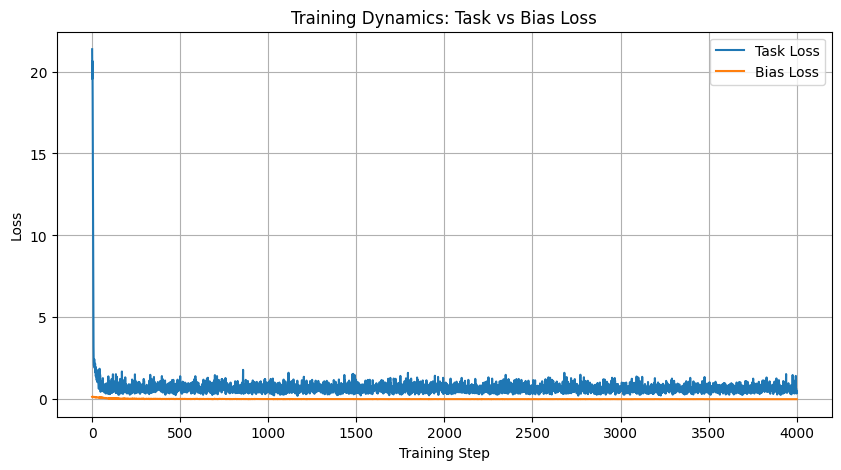

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["step"], df["task_loss"], label="Task Loss")
plt.plot(df["step"], df["bias_loss"], label="Bias Loss")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Dynamics: Task vs Bias Loss")
plt.legend()
plt.grid()

plt.show()

In [4]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 8.8 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 10.9 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


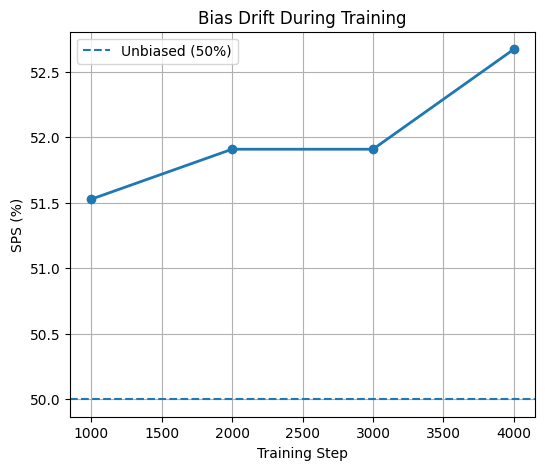

In [6]:
sps_df = df.dropna(subset=["sps"])

plt.figure(figsize=(6,5))

plt.plot(sps_df["step"], sps_df["sps"], marker="o", linewidth=2)

plt.axhline(50, linestyle="--", label="Unbiased (50%)")

plt.xlabel("Training Step")
plt.ylabel("SPS (%)")
plt.title("Bias Drift During Training")
plt.legend()
plt.grid()

plt.show()

In [12]:
!pip install python-dotenv

In [14]:
!pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]


In [15]:
import os
from dotenv import load_dotenv

load_dotenv()

hf_token = os.getenv("HF_KEY")

from huggingface_hub import login
login(hf_token)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

base_model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-hf",
    torch_dtype=torch.float16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model, "/Users/tishabhavsar/ADV-NLP/kaggle_outputs_2/best_model")
tokenizer = AutoTokenizer.from_pretrained("/Users/tishabhavsar/ADV-NLP/kaggle_outputs_2/best_model")

model.eval()

TypeError: LlamaForCausalLM.__init__() got an unexpected keyword argument 'assign'

In [ ]:
from datasets import load_dataset

dataset = load_dataset("glue", "sst2", split="validation")

In [ ]:
def create_prompt(text):
    return f"Review: {text}\nSentiment:"

In [ ]:
def predict(model, tokenizer, text):
    prompt = create_prompt(text)

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False
        )

    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract only generated part
    prediction = generated[len(prompt):].strip().lower()

    if "positive" in prediction:
        return 1
    elif "negative" in prediction:
        return 0
    else:
        return -1  # unclear

In [ ]:
dataset = dataset.select(range(200))

In [ ]:
correct = 0
total = 0
count = 0
curr_accuracy = 0
for example in dataset:
    pred = predict(model, tokenizer, example["sentence"])
    true = example["label"]

    if pred == -1:
        continue

    if pred == true:
        correct += 1
    count +=1 
    print("done with iteration", count)
    total += 1
    curr_accuracy = correct / total

accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")